In [1]:
import pandas as pd

In [2]:
exchange_rates = pd.read_csv('../../dataset/euro-daily-hist_1999_2020.csv')

In [3]:
exchange_rates.head()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2021-01-08,1.5758,1.9558,6.5748,1.5543,1.0827,7.9184,NaN,26.163,7.4369,...,4.8708,90.8000,10.0510,1.6228,NaN,NaN,36.8480,9.0146,1.2250,18.7212
1,2021-01-07,1.5836,1.9558,6.5172,1.5601,1.0833,7.9392,NaN,26.147,7.4392,...,4.8712,91.2000,10.0575,1.6253,NaN,NaN,36.8590,8.9987,1.2276,18.7919
2,2021-01-06,1.5824,1.9558,6.5119,1.5640,1.0821,7.9653,NaN,26.145,7.4393,...,4.8720,90.8175,10.0653,1.6246,NaN,NaN,36.9210,9.0554,1.2338,18.5123
3,2021-01-05,1.5927,1.9558,6.5517,1.5651,1.0803,7.9315,NaN,26.227,7.4387,...,4.8721,91.6715,10.0570,1.6180,NaN,NaN,36.7760,9.0694,1.2271,18.4194
4,2021-01-04,1.5928,1.9558,6.3241,1.5621,1.0811,7.9484,NaN,26.141,7.4379,...,4.8713,90.3420,10.0895,1.6198,NaN,NaN,36.7280,9.0579,1.2296,17.9214


In [4]:
exchange_rates.tail()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
5694,1999-01-08,1.8406,NaN,NaN,1.7643,1.6138,NaN,0.58187,34.938,7.4433,...,1.3143,27.2075,9.1650,1.9537,188.8400,42.560,42.5590,0.3718,1.1659,6.7855
5695,1999-01-07,1.8474,NaN,NaN,1.7602,1.6165,NaN,0.58187,34.886,7.4431,...,1.3092,26.9876,9.1800,1.9436,188.8000,42.765,42.1678,0.3701,1.1632,6.8283
5696,1999-01-06,1.8820,NaN,NaN,1.7711,1.6116,NaN,0.58200,34.850,7.4452,...,1.3168,27.4315,9.3050,1.9699,188.7000,42.778,42.6949,0.3722,1.1743,6.7307
5697,1999-01-05,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,34.917,7.4495,...,1.3168,26.5876,9.4025,1.9655,188.7750,42.848,42.5048,0.3728,1.1790,6.7975
5698,1999-01-04,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,35.107,7.4501,...,1.3111,25.2875,9.4696,1.9554,189.0450,42.991,42.6799,0.3723,1.1789,6.9358


In [5]:
exchange_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              5699 non-null   object 
 1   [Australian dollar ]      5699 non-null   object 
 2   [Bulgarian lev ]          5297 non-null   object 
 3   [Brazilian real ]         5431 non-null   object 
 4   [Canadian dollar ]        5699 non-null   object 
 5   [Swiss franc ]            5699 non-null   object 
 6   [Chinese yuan renminbi ]  5431 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           5699 non-null   object 
 9   [Danish krone ]           5699 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      5699 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       5699 non-null   object 
 14  [Croatia

In [6]:
exchange_rates.rename(columns={'[US dollar ]': 'US_dollar',
                               'Period\\Unit:': 'Time'},
                      inplace=True)
exchange_rates['Time'] = pd.to_datetime(exchange_rates['Time'])
exchange_rates.sort_values('Time', inplace=True)
exchange_rates.reset_index(drop=True, inplace=True)

In [7]:
euro_to_dollar = exchange_rates[['Time', 'US_dollar']]
print(euro_to_dollar)

           Time US_dollar
0    1999-01-04    1.1789
1    1999-01-05    1.1790
2    1999-01-06    1.1743
3    1999-01-07    1.1632
4    1999-01-08    1.1659
...         ...       ...
5694 2021-01-04    1.2296
5695 2021-01-05    1.2271
5696 2021-01-06    1.2338
5697 2021-01-07    1.2276
5698 2021-01-08    1.2250

[5699 rows x 2 columns]


In [8]:
euro_to_dollar['US_dollar'].value_counts()

US_dollar
-         62
1.2276     9
1.1215     8
1.1305     7
1.0867     6
          ..
1.1869     1
1.1752     1
1.1770     1
1.1750     1
1.1821     1
Name: count, Length: 3528, dtype: int64

In [9]:
euro_to_dollar = euro_to_dollar[euro_to_dollar['US_dollar'] != '-']
euro_to_dollar

,Time,US_dollar
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659
...,...,...
5694,2021-01-04,1.2296
5695,2021-01-05,1.2271
5696,2021-01-06,1.2338
5697,2021-01-07,1.2276


In [10]:
euro_to_dollar['US_dollar'] = euro_to_dollar['US_dollar'].astype(float)
euro_to_dollar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5637 entries, 0 to 5698
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Time       5637 non-null   datetime64[ns]
 1   US_dollar  5637 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 132.1 KB


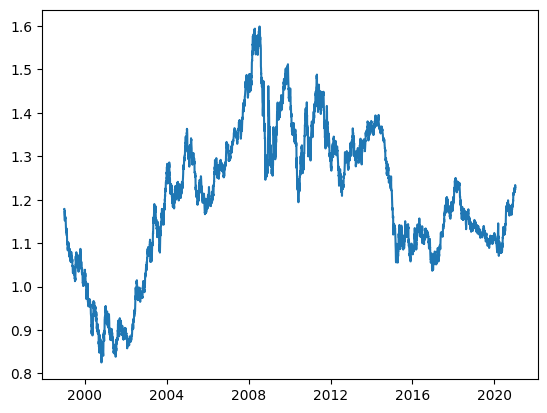

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(euro_to_dollar['Time'],
         euro_to_dollar['US_dollar'])
plt.show()

In [95]:
euro_to_dollar['rolling_mean'] = euro_to_dollar['US_dollar'].rolling(30).mean()
rolling_mean

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
5694    1.211170
5695    1.212530
5696    1.213987
5697    1.215357
5698    1.216557
Name: US_dollar, Length: 5637, dtype: float64

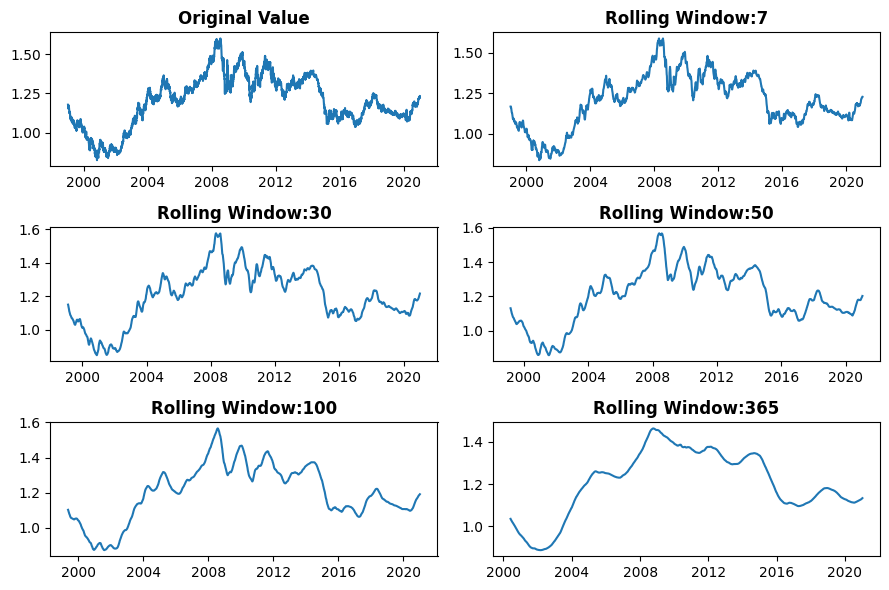

In [23]:
plt.figure(figsize=(9,6))
plt.subplot(3, 2, 1)
plt.plot(euro_to_dollar['Time'],
         euro_to_dollar['US_dollar'])
plt.title('Original Value', weight = 'bold')
for i, rolling in zip([2,3,4,5,6], [7, 30, 50, 100, 365]):
    plt.subplot(3,2, i)
    plt.plot(euro_to_dollar['Time'], euro_to_dollar['US_dollar'].rolling(rolling).mean())
    plt.title(f'Rolling Window:{rolling}', weight = 'bold')
plt.tight_layout()
plt.show()

In [97]:
import matplotlib.style as style
style.use('fivethirtyeight')

In [98]:
financial_crisis = euro_to_dollar.copy()[(euro_to_dollar['Time'].dt.year >= 2006) & (euro_to_dollar['Time'].dt.year <= 2009)]
financial_crisis_7_8 = euro_to_dollar.copy()[(euro_to_dollar['Time'].dt.year >= 2007) & (euro_to_dollar['Time'].dt.year <= 2008)]

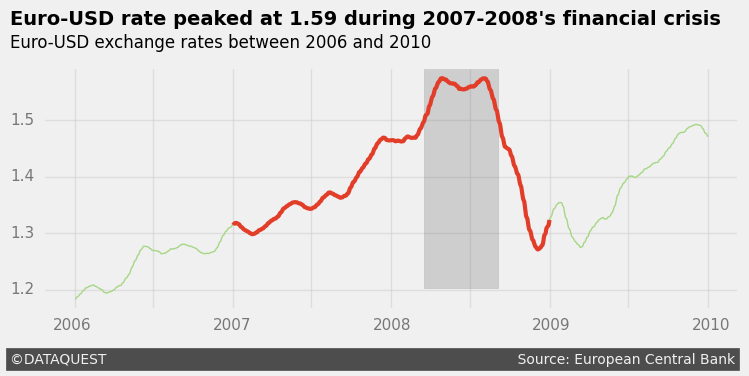

In [101]:
fig, ax = plt.subplots(figsize = (8,3))
ax.plot(financial_crisis['Time'], financial_crisis['rolling_mean'],linewidth=1, color='#A6D785')
ax.plot(financial_crisis_7_8['Time'], financial_crisis_7_8['rolling_mean'],linewidth=3, color='#e23d28')

ax.set_xticklabels([])
ax.set_yticklabels([])
### Highlihting the peak of the crisis
ax.axvspan(xmin=13955, xmax=14125, ymin=0.09,
           alpha=0.3, color='grey')
x = 13100.0
for year in ['2006', '2007', '2008', '2009', '2010']:
    ax.text(x, 1.13, year, alpha = 0.5, fontsize = 11)
    x+= 368
y = 1.193  
for rate in ['1.2', '1.3', '1.4', '1.5']:
    ax.text(13000.0, y , rate, alpha = 0.5, fontsize = 11)
    y+= 0.1
ax.text(13000, 1.67, "Euro-USD rate peaked at 1.59 during 2007-2008's financial crisis",weight = 'bold')
ax.text(13000, 1.63, 'Euro-USD exchange rates between 2006 and 2010' ,size = 12)
ax.text(13000, 1.07, '©DATAQUEST' + ' '*94 + 'Source: European Central Bank',
        color = '#f0f0f0', backgroundcolor = '#4d4d4d',
        size=10)
ax.grid(alpha=0.5)
plt.show()


In [119]:
bush_obama_trump = euro_to_dollar.copy()[(euro_to_dollar['Time'].dt.year >= 2001) & (euro_to_dollar['Time'].dt.year <= 2019)]
bush = euro_to_dollar.copy()[(euro_to_dollar['Time'].dt.year >= 2001) & (euro_to_dollar['Time'].dt.year < 2009)]

obama = euro_to_dollar.copy()[(euro_to_dollar['Time'].dt.year >= 2009) & (euro_to_dollar['Time'].dt.year < 2017)]
trump = euro_to_dollar.copy()[euro_to_dollar['Time'].dt.year >= 2017]

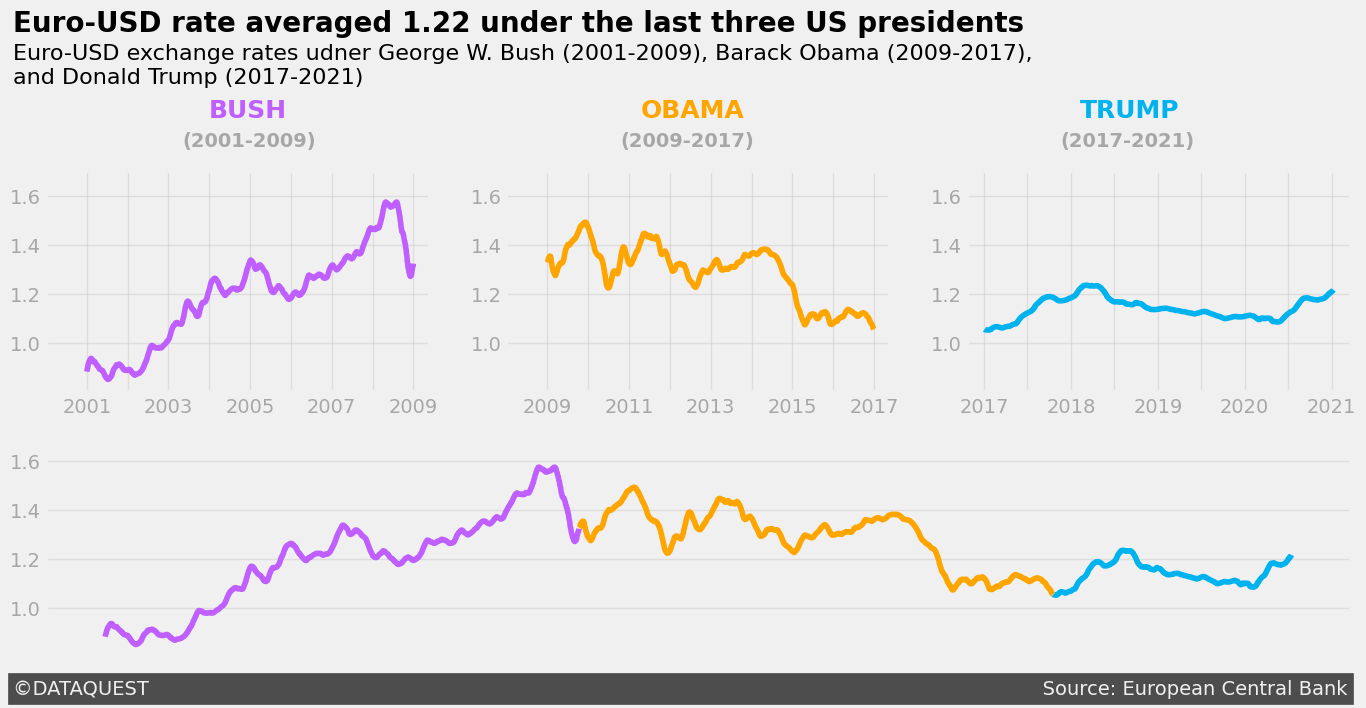

In [131]:
plt.figure(figsize = (15, 6), dpi = 100)
ax1 = plt.subplot(2,3,1)
ax2 = plt.subplot(2,3,2)
ax3 = plt.subplot(2,3,3)
ax4 = plt.subplot(2,1,2)

axes = [ax1, ax2, ax3, ax4]
for ax in axes:
    ax.set_ylim(0.8, 1.7)
    ax.set_yticks([1.0, 1.2, 1.4, 1.6])
    ax.set_yticklabels(['1.0', '1.2', '1.4', '1.6'], alpha = 0.3)
    ax.grid(alpha = 0.5)
    
#bush
### Ax1: Bush
ax1.plot(bush['Time'], bush['rolling_mean'], color='#BF5FFF')
ax1.set_xticks([10957, 11323, 11688, 12053, 12418, 12784, 13149, 13514, 13879, 14245])
ax1.set_xticklabels(['', '2001', '', '2003', '', '2005', '', '2007', '', '2009'], alpha=0.3)
ax1.text(12418, 1.92, 'BUSH', fontsize=18, weight='bold', color='#BF5FFF')
ax1.text(12180, 1.8, '(2001-2009)', weight='bold', alpha=0.3)

### Ax2: Obama
ax2.plot(obama['Time'], obama['rolling_mean'], color='#ffa500')
ax2.set_xticks([13879, 14245, 14610, 14975, 15340, 15706, 16071, 16436, 16801, 17167])
ax2.set_xticklabels(['', '2009', '', '2011', '', '2013', '', '2015', '', '2017'], alpha=0.3)
ax2.text(15079, 1.92, 'OBAMA', fontsize=18, weight='bold', color='#ffa500')
ax2.text(14899, 1.8, '(2009-2017)', weight='bold', alpha=0.3)

### Ax3: Trump
ax3.plot(trump['Time'], trump['rolling_mean'], color='#00B2EE')
ax3.set_xticks([17167, 17348, 17532, 17713, 17897, 18078, 18262, 18444, 18628])
ax3.set_xticklabels(['2017', '', '2018', '', '2019', '', '2020', '', '2021'], alpha=0.3)
ax3.text(17567, 1.92, 'TRUMP', fontsize=18, weight='bold', color='#00B2EE')
ax3.text(17485.0, 1.8, '(2017-2021)', weight='bold', alpha=0.3)

### Ax4: Bush-Obama-Trump
ax4.plot(bush['Time'], bush['rolling_mean'], color='#BF5FFF')
ax4.plot(obama['Time'], obama['rolling_mean'], color='#ffa500')
ax4.plot(trump['Time'], trump['rolling_mean'], color='#00B2EE')
ax4.grid(alpha=0.5)
ax4.set_xticks([])


ax.text(10757, 3.35, "Euro-USD rate averaged 1.22 under the last three US presidents",weight = 'bold', fontsize = 20)
ax.text(10757, 3.14, '''Euro-USD exchange rates udner George W. Bush (2001-2009), Barack Obama (2009-2017),
and Donald Trump (2017-2021)''' ,fontsize = 16)
ax.text(10757, 0.65, '©DATAQUEST' + ' '*143 + 'Source: European Central Bank',
        color = '#f0f0f0', backgroundcolor = '#4d4d4d',
        size=14)

plt.show()
